## Module 8 — Iterative / Looping Workflows in LangGraph

The fourth and final type of workflow — loops allow you to repeat a set of tasks until a condition is met, rather than executing linearly from start to end.

---

### 🔄 What is an Iterative Workflow?

A looping workflow runs nodes in a cycle — repeatedly improving something until it meets a quality bar.
```
START → generate_post → evaluate
                            ↓ [approved]     → END
                            ↓ [needs improvement] → optimize → evaluate (loop back)
```

> 📌 *The loop only exits when the evaluator approves the post. If not approved, the optimizer improves it and sends it back to the evaluator — this cycle repeats as many times as needed.*

---

### 🧑‍💻 Use Case — LinkedIn/X Post Generator

**The problem:** LLMs rarely produce a great social media post on the first attempt. Quality is inconsistent.

**The solution:** An iterative workflow with three components:

| Component | Role | LLM? |
|---|---|---|
| **Generator** | Creates a post from a given topic | ✅ |
| **Evaluator** | Scores the post against strict criteria — approves or rejects with feedback | ✅ |
| **Optimizer** | Takes the post + evaluator feedback and rewrites an improved version | ✅ |

**Flow:**
- If evaluator approves → workflow ends
- If evaluator rejects → optimizer rewrites → evaluator re-evaluates → loop continues

> 💡 *In a real production system, an approved post wouldn't go straight to END — a human-in-the-loop step would show the post to a human for final approval before publishing via API. We'll cover HITL in a later module.*

---


---

### 🐦 Workflow — Viral Tweet Generator (Iterative)

An LLM-based looping workflow that keeps refining a tweet until it meets a quality bar — or hits the max iteration limit.

**Flow:**
```
START → generate → evaluate
                      ↓ [approved or max iterations reached] → END
                      ↓ [needs_improvement] → optimize → evaluate (loop)
```

---

#### Setup

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
import operator
from dotenv import load_dotenv
load_dotenv(override=True)
import warnings
warnings.filterwarnings("ignore")

# three separate LLMs — each tuned for its specific role
generator_llm = ChatOpenAI(model='gpt-4o')        # strong writer for generation
evaluator_llm = ChatOpenAI(model='gpt-4o-mini')   # strict judge for evaluation
optimizer_llm = ChatOpenAI(model='gpt-4o')        # strong rewriter for optimization

> 📌 *In a production system, pick each LLM based on what it does best. Generation and optimization need strong creative writing; evaluation needs strict, reliable instruction-following. Swapping models here is as simple as changing the model string.*

---

#### Structured Output Schema

In [2]:
class TweetEvaluation(BaseModel):
    """Schema to enforce structured evaluator output — verdict + feedback."""
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result")
    feedback: str = Field(..., description="Constructive feedback for the tweet")

structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

> 📌 *Structured output is critical here — the evaluator's verdict directly drives the routing decision. If it returns free text instead of `"approved"` or `"needs_improvement"`, the conditional edge breaks.*

---

#### State

In [3]:
class TweetState(TypedDict):
    topic: str                                              # input — tweet topic
    tweet: str                                              # current best tweet
    evaluation: Literal["approved", "needs_improvement"]   # latest evaluator verdict
    feedback: str                                           # latest evaluator feedback
    iteration: int                                          # current loop count
    max_iteration: int                                      # loop safety limit
    tweet_history: Annotated[list[str], operator.add]      # all tweet versions (reducer)
    feedback_history: Annotated[list[str], operator.add]   # all feedback versions (reducer)

> 📌 *`tweet_history` and `feedback_history` use `operator.add` reducer — every new tweet and feedback gets appended rather than overwritten. This lets you trace the full evolution of the tweet across iterations.*

> 📌 *`max_iteration` is a safety valve — without it, a too-strict evaluator + too-weak model could loop infinitely. Always include a loop limit in iterative workflows.*

---

#### Nodes

In [4]:
def generate_tweet(state: TweetState):
    """Generate an original, funny tweet on the given topic."""
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".
        
        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """)
    ]
    response = generator_llm.invoke(messages).content
    # store tweet and append to history
    return {"tweet": response, "tweet_history": [response]}


def evaluate_tweet(state: TweetState):
    """Evaluate the current tweet against strict quality criteria."""
    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets."),
        HumanMessage(content=f"""
            Evaluate the following tweet:
            
            Tweet: "{state['tweet']}"
            
            Criteria:
            1. Originality — Is this fresh or seen a hundred times?
            2. Humor — Did it genuinely make you smile or laugh?
            3. Punchiness — Is it short, sharp, and scroll-stopping?
            4. Virality Potential — Would people retweet or share it?
            5. Format — Well-formed tweet, not Q&A, not setup-punchline, under 280 characters?
            
            Auto-reject if:
            - Written in question-answer format
            - Exceeds 280 characters
            - Reads like a traditional setup-punchline joke
            - Ends with generic deflating lines that weaken the humor
            
            Respond ONLY in structured format:
            evaluation: "approved" or "needs_improvement"
            feedback: One paragraph explaining strengths and weaknesses
            """)
    ]
    response = structured_evaluator_llm.invoke(messages)
    return {"evaluation": response.evaluation, "feedback": response.feedback, "feedback_history": [response.feedback]}


def optimize_tweet(state: TweetState):
    """Rewrite the tweet based on evaluator feedback to improve quality."""
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
                HumanMessage(content=f"""
        Improve the tweet based on this feedback:
        
        "{state['feedback']}"
        
        Topic: "{state['topic']}"
        
        Original Tweet:
        {state['tweet']}
        
        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)
    ]
    response = optimizer_llm.invoke(messages).content
    # increment iteration counter each time optimizer runs
    return {"tweet": response, "iteration": state["iteration"] + 1, "tweet_history": [response]}

> 📌 *`SystemMessage` + `HumanMessage` from LangChain allows separating persona (system) from task (human) in the prompt — gives LLMs clearer context than a single flat string.*

---

#### Routing Function

In [5]:
def route_evaluation(state: TweetState) -> Literal["approved", "needs_improvement"]:
    """Exit the loop if tweet is approved OR max iterations reached."""
    if state["evaluation"] == "approved" or state["iteration"] >= state["max_iteration"]:
        return "approved"   # exit loop → go to END
    else:
        return "needs_improvement"  # continue loop → go to optimize

> 📌 *Two exit conditions — the tweet gets approved, OR we've hit 5 iterations. The second condition is the safety valve that prevents infinite loops regardless of evaluator strictness.*

---

#### Graph

In [6]:
graph = StateGraph(TweetState)

graph.add_node("generate", generate_tweet)
graph.add_node("evaluate", evaluate_tweet)
graph.add_node("optimize", optimize_tweet)

graph.add_edge(START, "generate")
graph.add_edge("generate", "evaluate")

# conditional edge — routes to END or optimize based on evaluation
graph.add_conditional_edges(
    "evaluate",
    route_evaluation,
    {"approved": END, "needs_improvement": "optimize"}  # explicit mapping
)

# this single edge creates the loop — optimize feeds back into evaluate
graph.add_edge("optimize", "evaluate")

workflow = graph.compile()

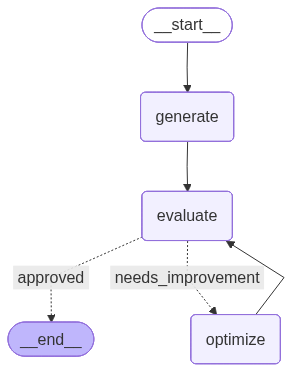

In [9]:
workflow

> 📌 *The loop is just two edges working together — `add_conditional_edges` sends to `optimize` when rejected, and `add_edge("optimize", "evaluate")` sends straight back. That's all it takes to create a loop in LangGraph.*

> 📌 *`add_conditional_edges` with an explicit dict `{"approved": END, "needs_improvement": "optimize"}` maps routing function return values directly to destination nodes — cleaner and more readable than relying on implicit matching.*

---

#### Run

In [7]:
initial_state = {
    "topic": "Indian Railways",
    "iteration": 1,
    "max_iteration": 5,
    "tweet_history": [],
    "feedback_history": []
}

final_state = workflow.invoke(initial_state)

print(final_state["tweet"])           # best tweet after all iterations
print(final_state["iteration"])       # how many loops it took
print(final_state["tweet_history"])   # all versions generated
print(final_state["feedback_history"]) # all feedback received

All aboard the Indian Railways! When the train's clock is just a decoration, but the chai wala is the real MVP, always punctual. Sip the chaos, embrace the journey! 🚂☕ #ChaiChronicles #TrainTales #UnscheduledAdventures
5
['Indian Railways: the only place where "on time" is a mythical creature and every journey is a surprise party where the guest of honor, your train, might just not show up. 🚂✨ #TimeTravelWithIRCTC', 'Indian Railways: where time is a suggestion and train schedules are as mysterious as black holes. Hold tight, your journey might just be the most unpredictable adventure yet! 🚂🌀 #TrainTwilightZone', 'All aboard the Indian Railways, where "on time" is just a wild rumor and the real journey is guessing when you\'ll arrive! Expect delays, drama, and maybe an on-train novella. 📚🚂 #RailwayAdventures #UnscheduledFun', 'Riding the Indian Railways: where your destination time is just a suggestion and the chai vendor is always on time! 🚂✨ Embrace the unpredictability—next stop, whe

---

> 📌 *In a real production system this workflow wouldn't end at `END` — an approved tweet would go to a HITL (Human-in-the-Loop) step where a human gives final sign-off before publishing via platform API. HITL is covered in a later module.*

---

#### 🔑 How Loops Work in LangGraph
```
No special "loop" syntax exists — loops are just edges pointing backwards.

optimize → evaluate   # this single edge creates the loop
```

| To create a loop you need | Why |
|---|---|
| A conditional edge | Decides when to loop vs when to exit |
| A backward edge | Sends execution back to an earlier node |
| A termination condition | Prevents infinite loops |
| A safety limit (`max_iteration`) | Backup exit in case condition never triggers |

---


In [8]:
initial_state = {
    "topic": "Indian IT workers",
    "iteration": 1,
    "max_iteration": 5,
    "tweet_history": [],
    "feedback_history": []
}

final_state = workflow.invoke(initial_state)

print(final_state["tweet"])           # best tweet after all iterations
print(final_state["iteration"])       # how many loops it took
print(final_state["tweet_history"])   # all versions generated
print(final_state["feedback_history"]) # all feedback received

"Indian IT pros be like, 'Hold my chai,' and suddenly the server is running smoother than a Bollywood dance number. Powered by code, spice, and a sprinkle of magic! ☕💻✨ #DesiTechWiz #ChaiCharge"
5
["When an Indian IT worker says they’ll fix it in a minute, you better bring a chai and snacks, because you're in for a masterclass on time zones, Star Wars references, and the sacred art of turning it off and on again. 🖥️☕#TechWizardry", 'When an Indian IT wizard says, "Give me a sec," buckle up for a ride through time zones, with tech magic worthy of Hogwarts and Jedi wisdom—no snacks needed unless they\'re sharing their secret coding fuel. 🧙\u200d♂️💻 #TechSorcery #NotYourAverageHelpDesk', 'When an Indian IT wizard says, "Give me a sec," prepare for tech magic straight outta Hogwarts with Jedi-level wisdom. All powered by mystery coding snacks. 🧙\u200d♂️💻 #TechSorcery #AccioSolution', 'When an Indian IT pro says, "Hold my chai," expect tech sorcery that rivals Hogwarts and Jedi mind tricks.